Load historical data

In [1]:
import pandas as pd

df = pd.read_csv(
    "interior_design_prices.csv",
    parse_dates=["Date"]
)

print(df.shape)
display(df.head())

(80946, 6)


,Date,Category,Sub_Category,Product_Name,Price,Source
0,2022-01-01,Furniture,Sofa Sets,3 seater,70547.57,Urbanladder.com
1,2022-02-01,Furniture,Sofa Sets,3 seater,74105.80,Urbanladder.com
2,2022-03-01,Furniture,Sofa Sets,3 seater,75399.20,Urbanladder.com
3,2022-04-01,Furniture,Sofa Sets,3 seater,75288.51,Urbanladder.com
4,2022-05-01,Furniture,Sofa Sets,3 seater,76820.34,Urbanladder.com


Basic information

In [2]:
print("Rows:", len(df))
print("Products:", df["Product_Name"].nunique())
print("Categories:", df["Category"].nunique())
print("Subcategories:", df["Sub_Category"].nunique())

display(
    df.groupby("Category")
      .agg(
          Products=("Product_Name","nunique"),
          Avg_Price=("Price","mean")
      )
)

Rows: 80946
Products: 33
Categories: 4
Subcategories: 21


,Products,Avg_Price
Category,,
Decor,4,4643.783980
Flooring,14,92.530977
Furniture,10,41689.263100
Lighting,5,7089.980072


Feature engineering

In [3]:
df["Year"] = df["Date"].dt.year
df["Month"] = df["Date"].dt.month
df["Quarter"] = df["Date"].dt.quarter

#Lag feature
df = df.sort_values(
    ["Product_Name","Date"]
)

df["Lag_1"] = (
    df.groupby("Product_Name")["Price"]
      .shift(1)
)

df["Lag_2"] = (
    df.groupby("Product_Name")["Price"]
      .shift(2)
)

df["Lag_3"] = (
    df.groupby("Product_Name")["Price"]
      .shift(3)
)

df["Rolling_Mean_3"] = (
    df.groupby("Product_Name")["Price"]
      .transform(
          lambda x:
          x.rolling(3).mean()
      )
)

Exploratory data analysis

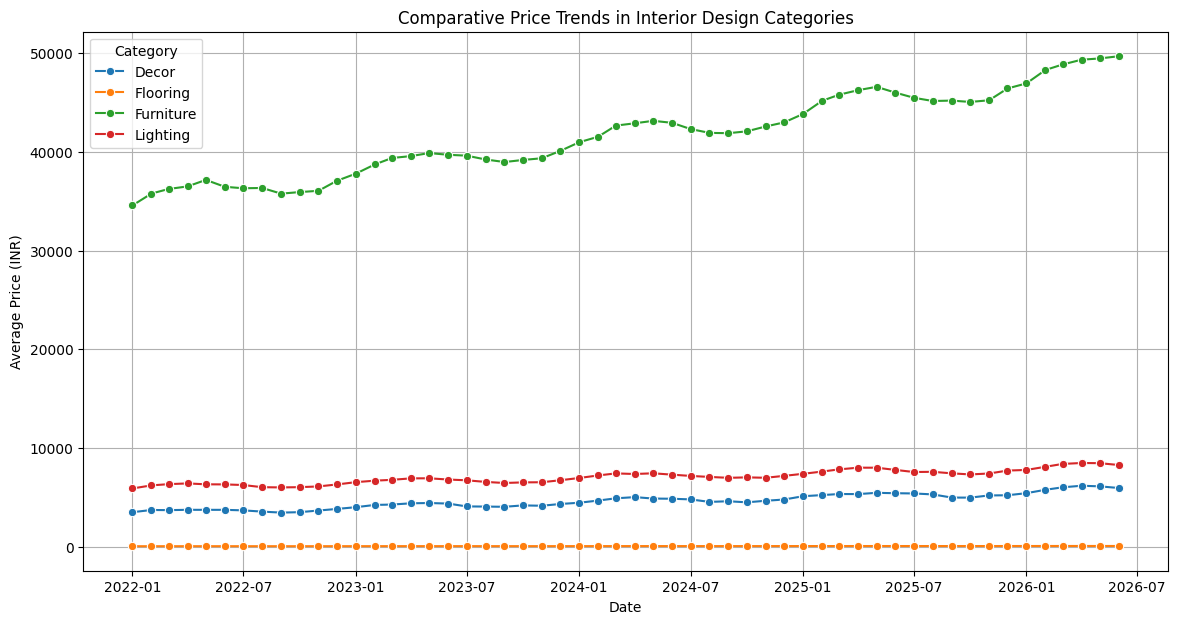

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

# Average monthly price per category
monthly_category = (
    df.groupby(["Date", "Category"])["Price"]
      .mean()
      .reset_index()
)

plt.figure(figsize=(14, 7))

sns.lineplot(
    data=monthly_category,
    x="Date",
    y="Price",
    hue="Category",
    marker="o"
)

plt.title("Comparative Price Trends in Interior Design Categories")
plt.xlabel("Date")
plt.ylabel("Average Price (INR)")
plt.grid(True)
plt.legend(title="Category")

plt.show()

Growth analysis

In [5]:
#Create monthly avg prices by category
df_sorted = (
    df.groupby(["Date","Category"])["Price"]
    .mean()
    .reset_index()
    .sort_values(["Category","Date"])
)

#Monthly returns
df_sorted["Monthly_Return"] = df_sorted.groupby("Category")["Price"].pct_change()

summary = (
    df_sorted.groupby("Category")
    .agg(
        Start_Price=("Price", "first"),
        End_Price=("Price", "last"),
        Months=("Price", "count"),
        Avg_Monthly_Return=("Monthly_Return", "mean"),
        Volatility=("Monthly_Return", "std")
    )
    .reset_index()
)

# CAGR calculation
def calc_cagr(start, end, months):
    years = months / 12
    return (end/start)**(1/years) - 1

summary["CAGR"] = (
    summary.apply(
        lambda r:
        calc_cagr(
            r["Start_Price"],
            r["End_Price"],
            r["Months"]
        ),
        axis=1
    )
)

display(summary)

,Category,Start_Price,End_Price,Months,Avg_Monthly_Return,Volatility,CAGR
0,Decor,3522.834965,5970.529255,54,0.010497,0.031787,0.124387
1,Flooring,80.211536,105.465607,54,0.005207,0.007783,0.062714
2,Furniture,34563.313583,49659.091771,54,0.006941,0.012808,0.083862
3,Lighting,5924.104955,8295.974887,54,0.006604,0.021758,0.077702


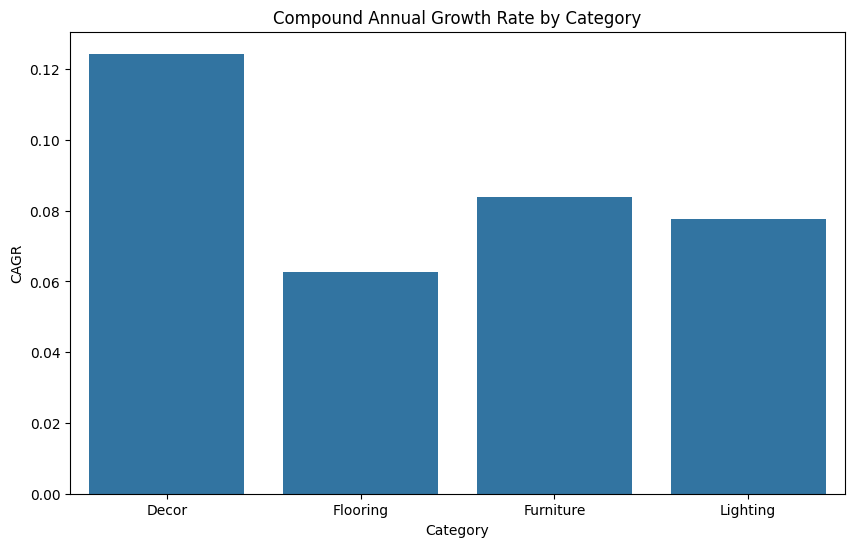

In [6]:
#CAGR chart
plt.figure(figsize=(10, 6))

sns.barplot(
    data=summary,
    x="Category",
    y="CAGR"
)

plt.title("Compound Annual Growth Rate by Category")
plt.ylabel("CAGR")
plt.show()

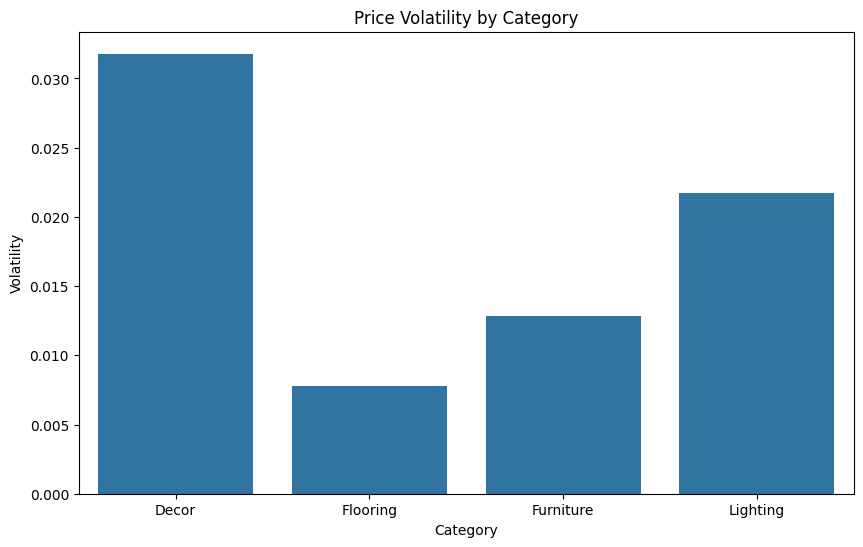

In [7]:
#Volatility chart
plt.figure(figsize=(10, 6))

sns.barplot(
    data=summary,
    x="Category",
    y="Volatility"
)

plt.title("Price Volatility by Category")
plt.ylabel("Volatility")
plt.show()

Forecasting

In [8]:
# Forecasting

!pip install prophet

In [9]:
from prophet import Prophet

In [10]:
#Subcategory time series
subcat_df = (
    df.groupby(
        ["Date", "Sub_Category"]
    )["Price"]
    .mean()
    .reset_index()
)

print(subcat_df.shape)
display(subcat_df.head())

(1134, 3)


,Date,Sub_Category,Price
0,2022-01-01,Artifical Plants,424.250139
1,2022-01-01,Beds,33131.545145
2,2022-01-01,Ceiling Lights,6345.091449
3,2022-01-01,Chandeliers,10035.154286
4,2022-01-01,Dining Table,67406.609552



==== Forecasting: Artifical Plants ====


INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.


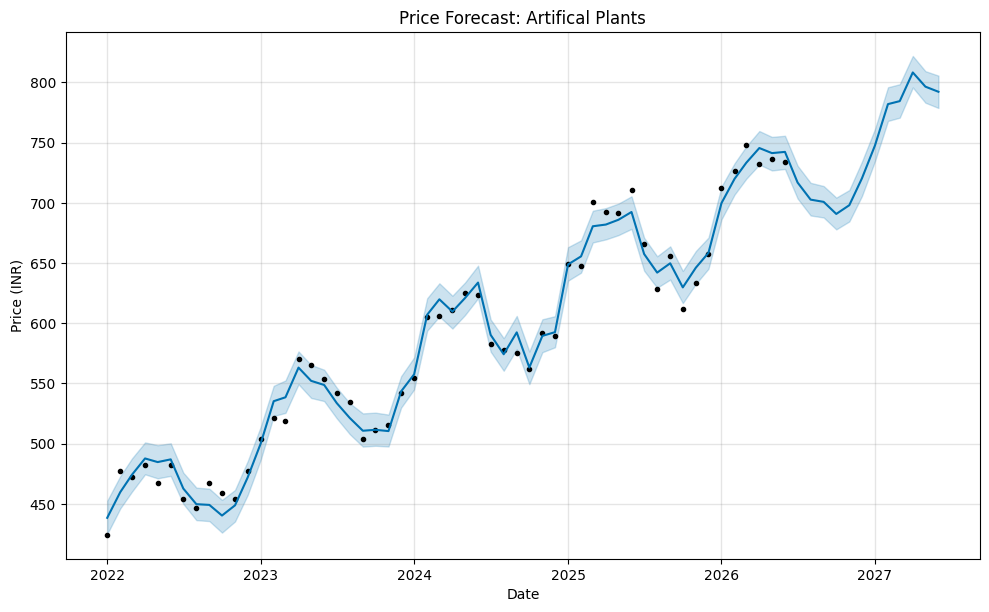

INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.


Saved: forecast_Artifical Plants.csv

==== Forecasting: Beds ====


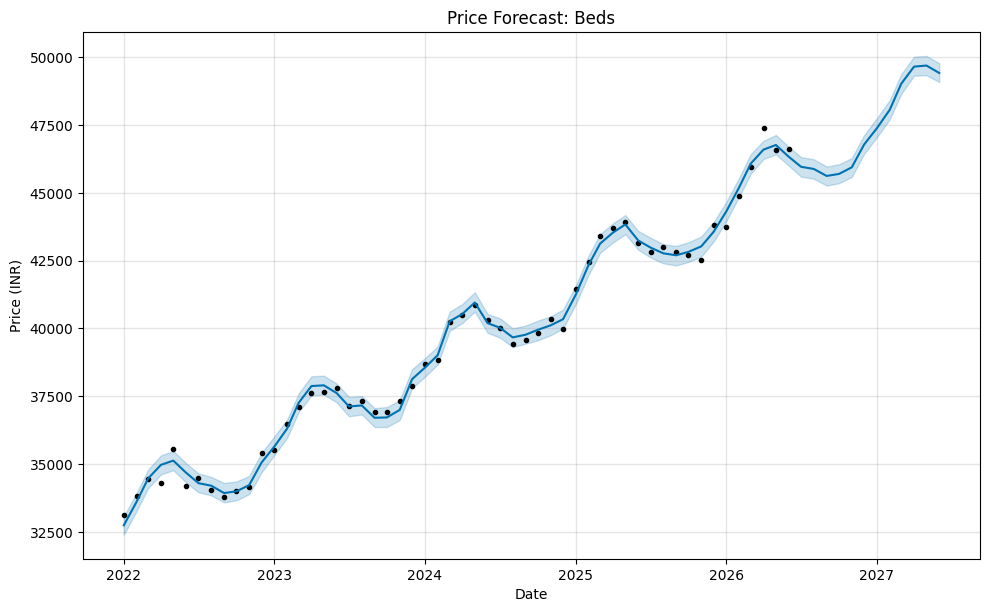

INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.


Saved: forecast_Beds.csv

==== Forecasting: Ceiling Lights ====


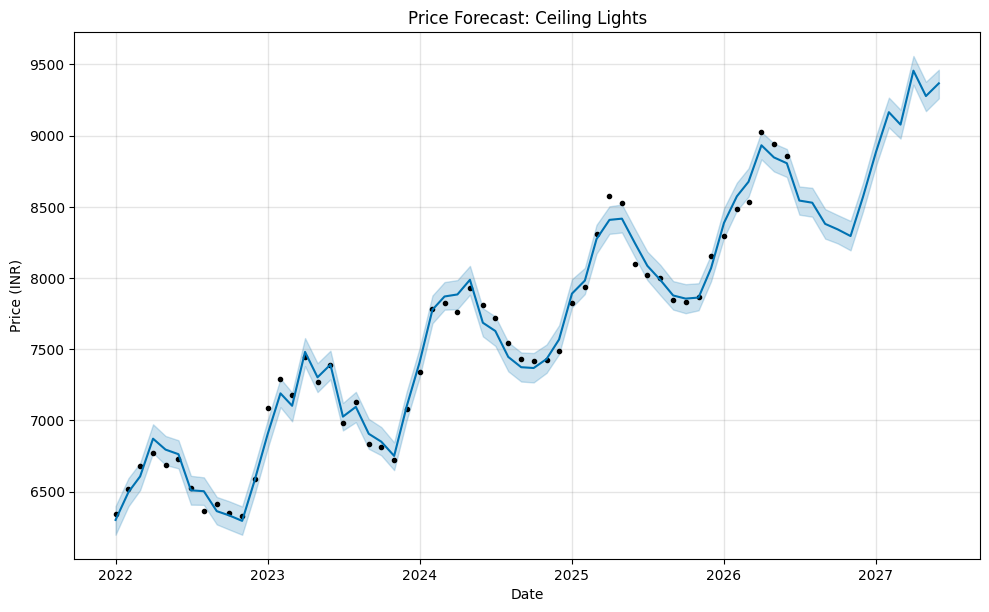

INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.


Saved: forecast_Ceiling Lights.csv

==== Forecasting: Chandeliers ====


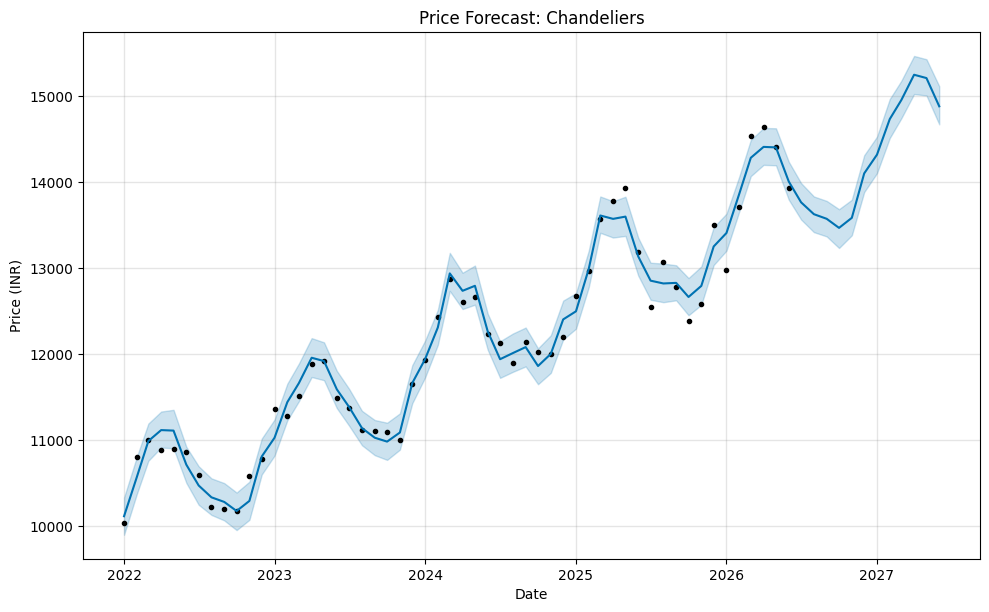

INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.


Saved: forecast_Chandeliers.csv

==== Forecasting: Dining Table ====


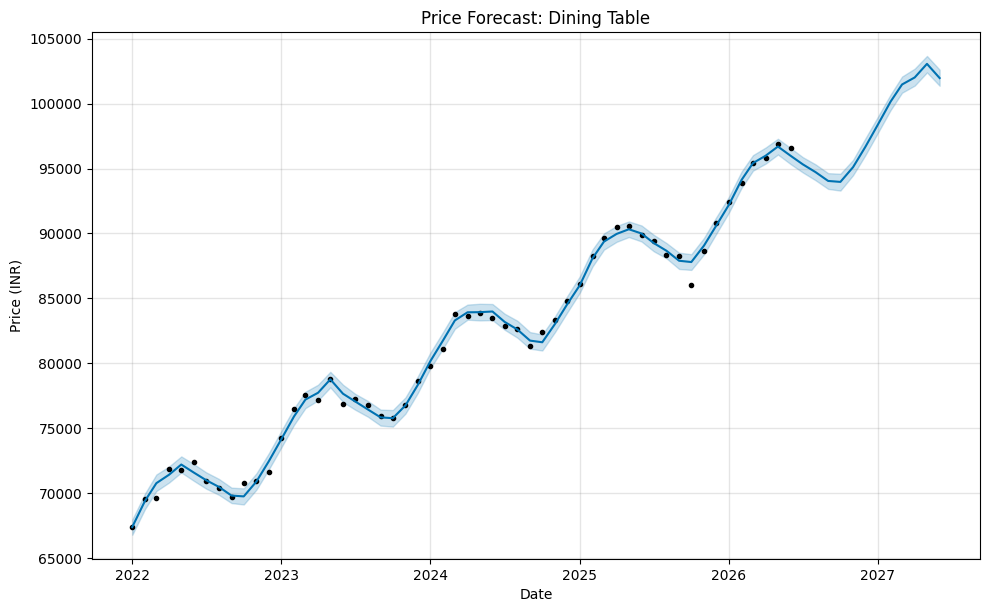

INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.


Saved: forecast_Dining Table.csv

==== Forecasting: Floor Lamps ====


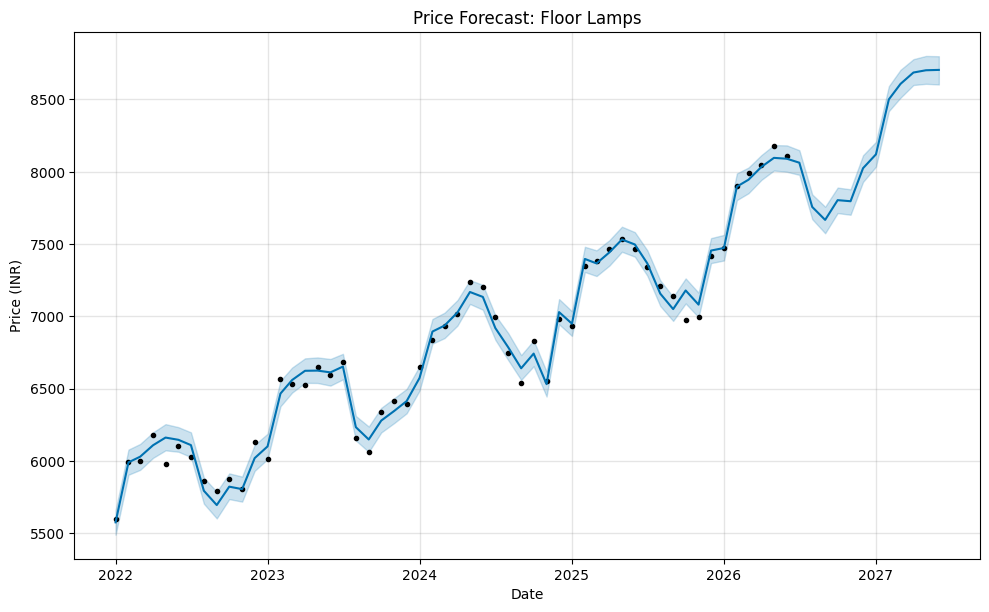

INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.


Saved: forecast_Floor Lamps.csv

==== Forecasting: Hanging Lights ====


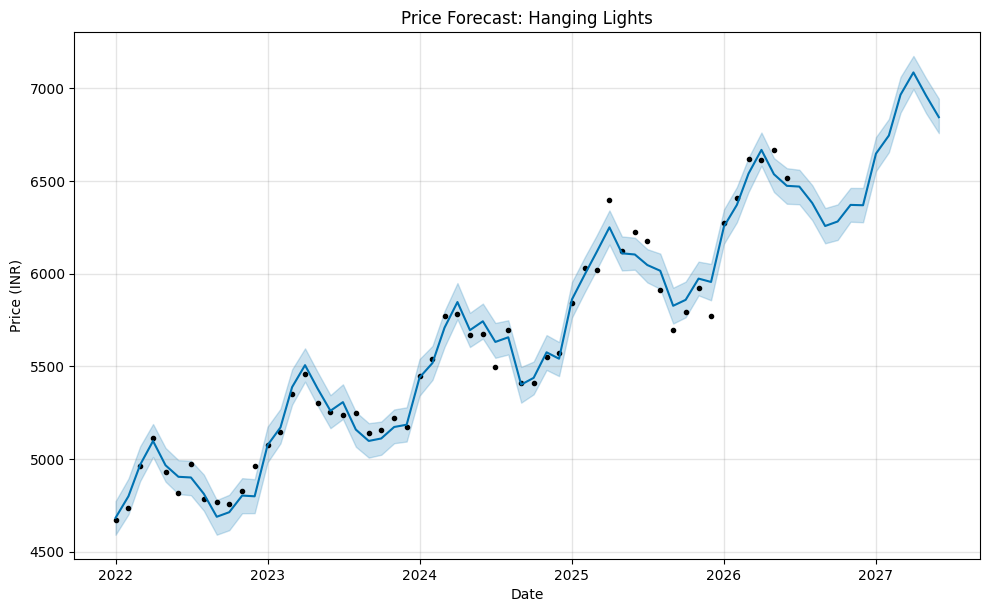

INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.


Saved: forecast_Hanging Lights.csv

==== Forecasting: Recliner Sofas ====


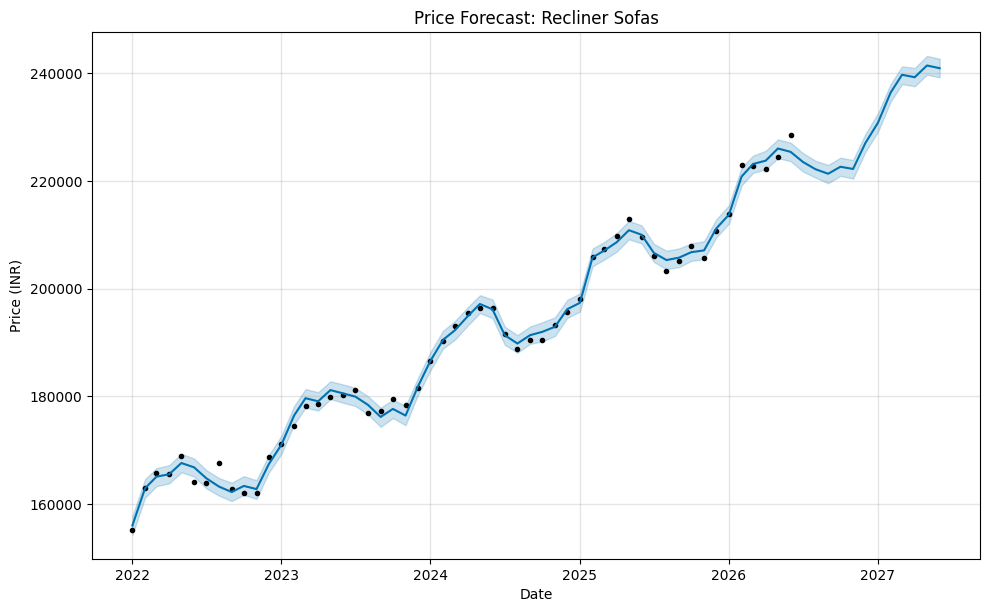

INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.


Saved: forecast_Recliner Sofas.csv

==== Forecasting: Showpieces ====


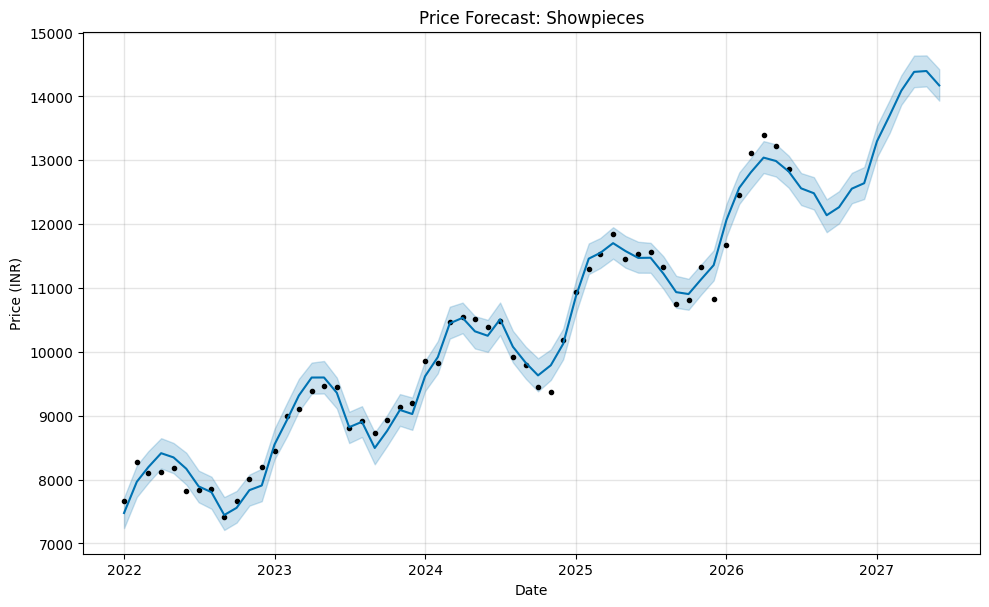

INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.


Saved: forecast_Showpieces.csv

==== Forecasting: Sofa Cum Beds ====


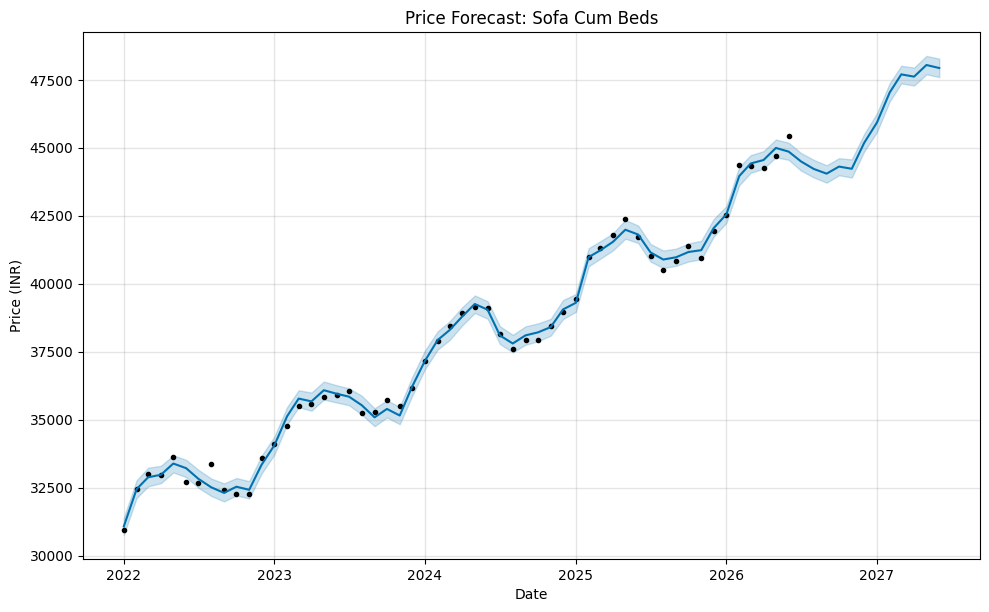

INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.


Saved: forecast_Sofa Cum Beds.csv

==== Forecasting: Sofa Sets ====


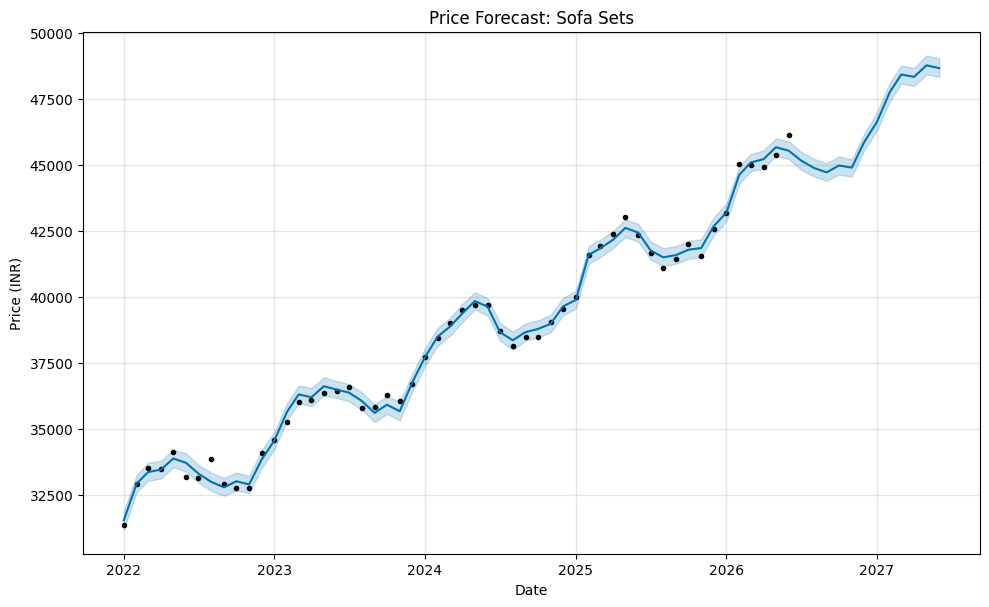

INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.


Saved: forecast_Sofa Sets.csv

==== Forecasting: Stone ====


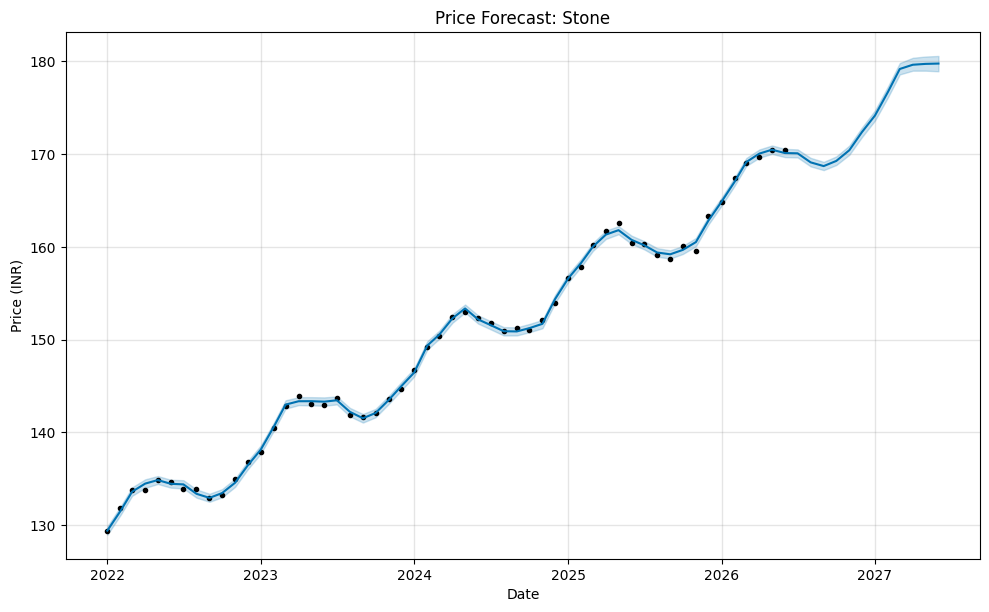

INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.


Saved: forecast_Stone.csv

==== Forecasting: Study Table ====


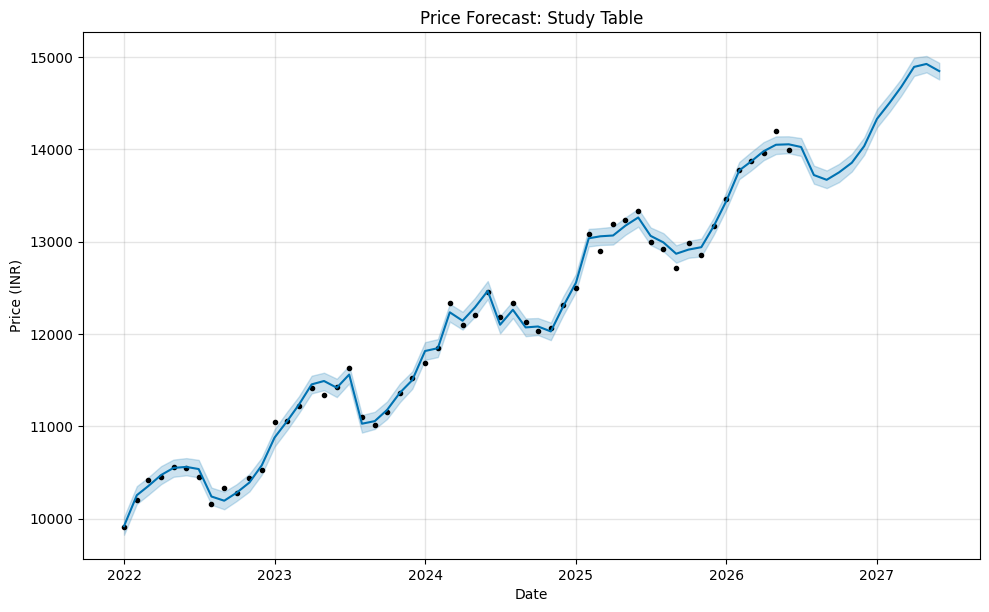

INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.


Saved: forecast_Study Table.csv

==== Forecasting: Tile ====


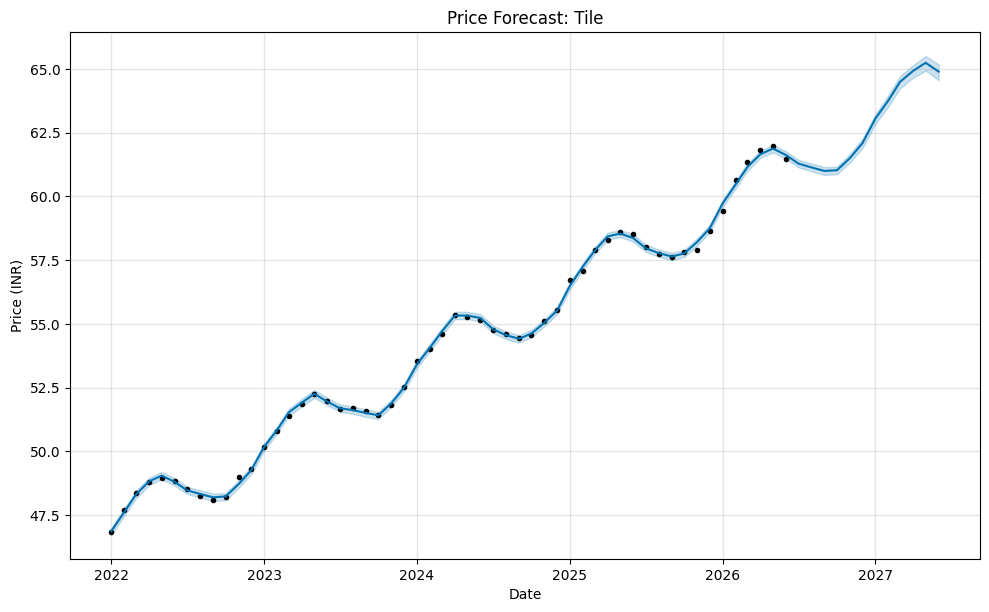

INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.


Saved: forecast_Tile.csv

==== Forecasting: Tiles ====


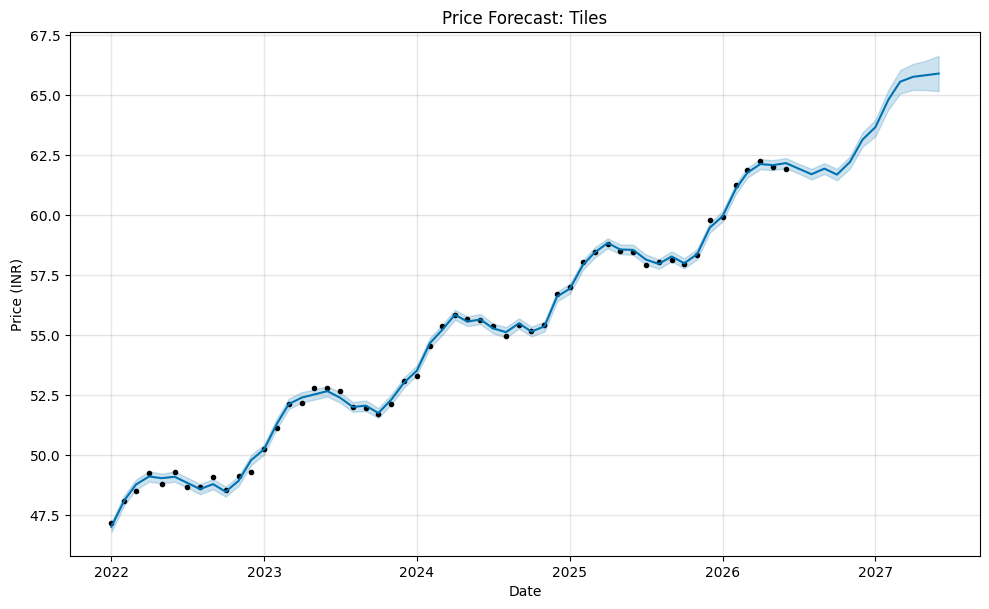

INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.


Saved: forecast_Tiles.csv

==== Forecasting: Vases ====


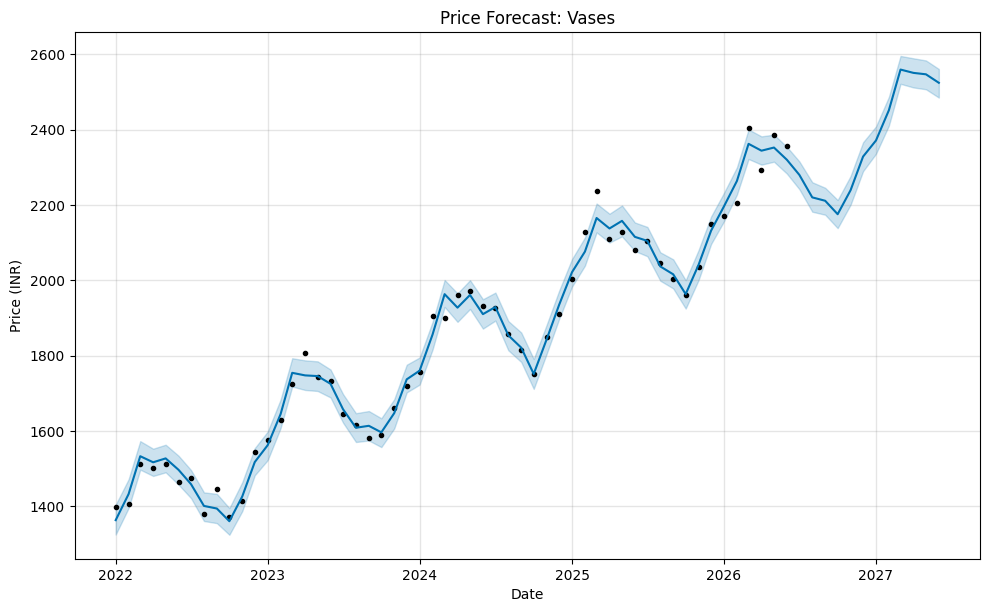

INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.


Saved: forecast_Vases.csv

==== Forecasting: Vinyl ====


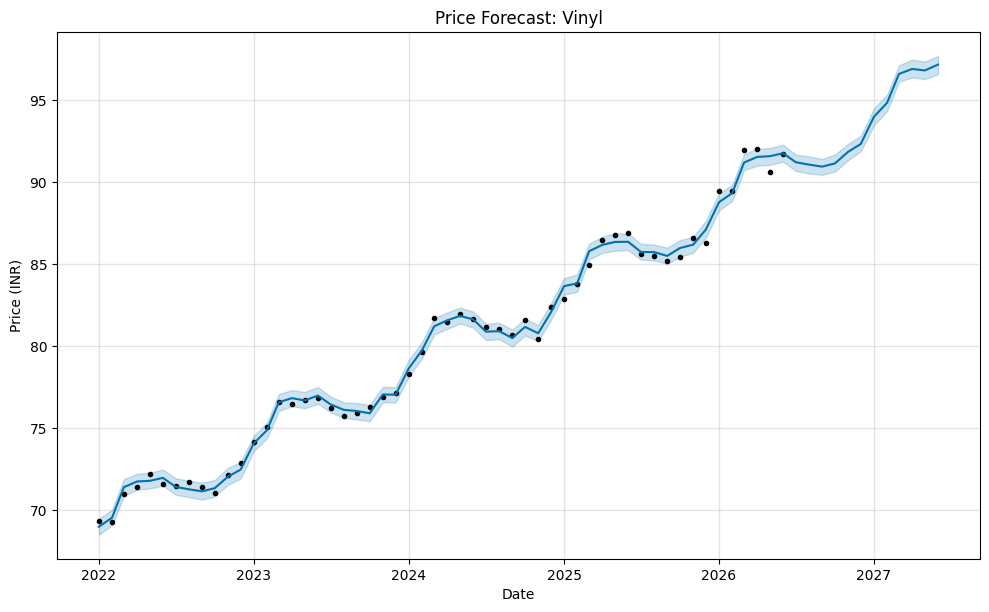

INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.


Saved: forecast_Vinyl.csv

==== Forecasting: Wall Decor ====


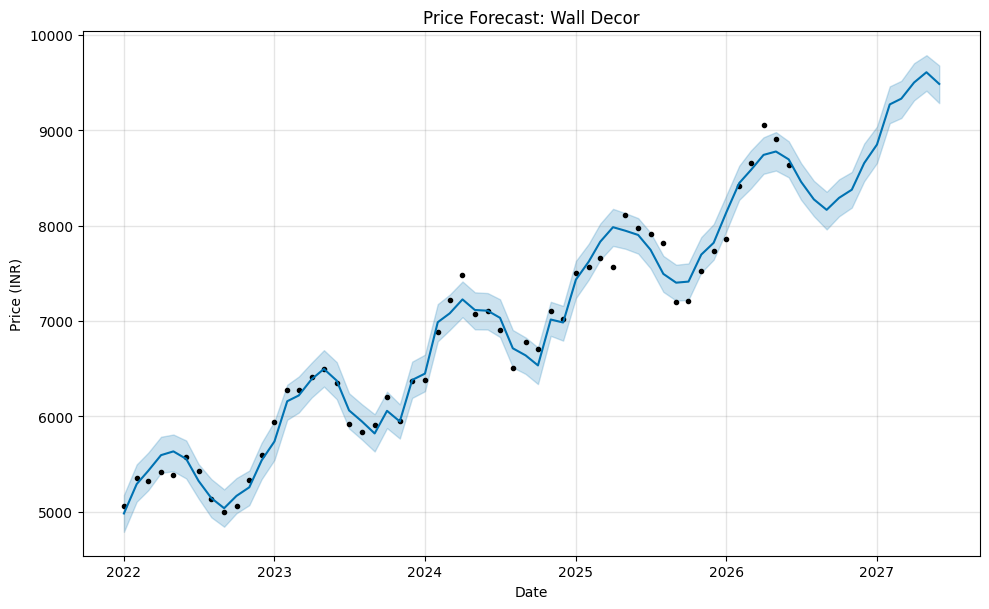

INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.


Saved: forecast_Wall Decor.csv

==== Forecasting: Wall Lights ====


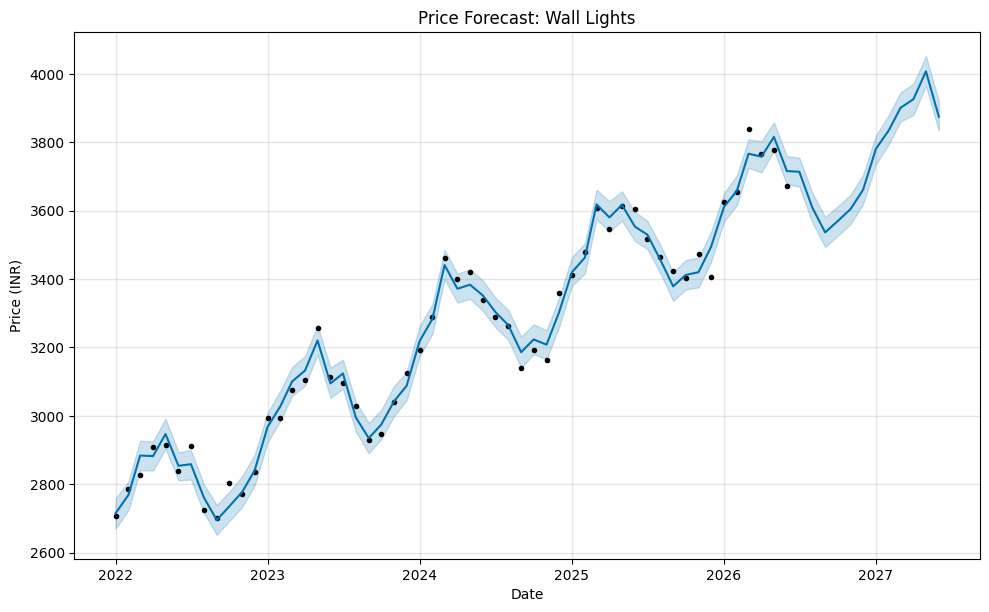

INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.


Saved: forecast_Wall Lights.csv

==== Forecasting: Wardrobes ====


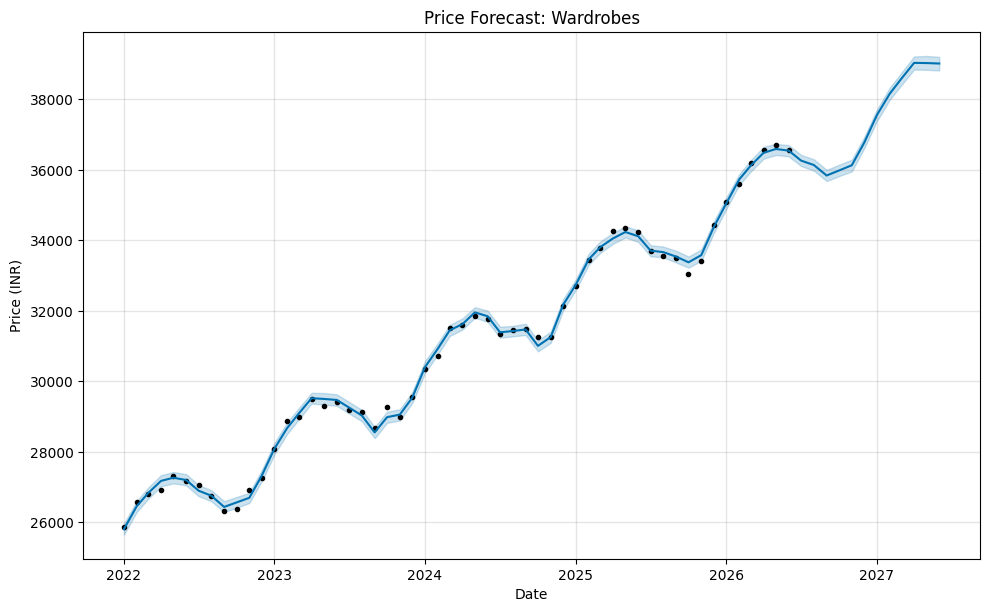

INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.


Saved: forecast_Wardrobes.csv

==== Forecasting: Wood ====


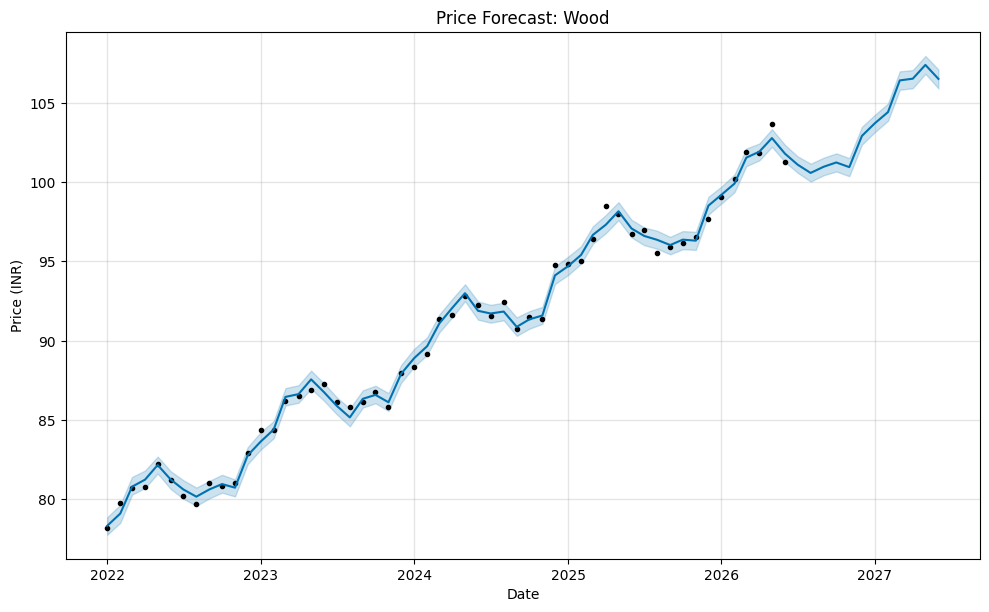

Saved: forecast_Wood.csv


In [11]:
from prophet import Prophet

subcats = (
    subcat_df["Sub_Category"]
    .unique()
)

all_forecasts = {}

for subcat in subcats:

    print(
        f"\n==== Forecasting: {subcat} ===="
    )

    ts = (
        subcat_df[
            subcat_df["Sub_Category"]
            == subcat
        ]
        .rename(
            columns={
                "Date": "ds",
                "Price": "y"
            }
        )
    )

    model = Prophet()

    model.fit(ts)

    future = (
        model.make_future_dataframe(
            periods=12,
            freq="MS"
        )
    )

    forecast = model.predict(
        future
    )

    all_forecasts[subcat] = forecast

    fig1 = model.plot(
        forecast
    )

    plt.title(
        f"Price Forecast: {subcat}"
    )

    plt.xlabel("Date")
    plt.ylabel("Price (INR)")
    plt.show()

    out_path = (
        f"forecast_{subcat}.csv"
    )

    forecast[
        [
            "ds",
            "yhat",
            "yhat_lower",
            "yhat_upper"
        ]
    ].to_csv(
        out_path,
        index=False
    )

    print(
        "Saved:",
        out_path
    )

In [12]:
future_summary = []

for subcat, forecast in all_forecasts.items():

    tail = forecast.tail(12)

    future_summary.append(
        {
            "Sub_Category":
            subcat,

            "Avg_Predicted_Price_Next12M":
            tail["yhat"].mean()
        }
    )

future_summary_df = pd.DataFrame(
    future_summary
)

display(
    future_summary_df
)

future_summary_df.to_csv(
    "future_summary_next12m.csv",
    index=False
)

print(
    "Saved: future_summary_next12m.csv"
)

,Sub_Category,Avg_Predicted_Price_Next12M
0,Artifical Plants,745.005473
1,Beds,47423.189559
2,Ceiling Lights,8823.230438
3,Chandeliers,14290.211844
4,Dining Table,98073.778682
5,Floor Lamps,8202.420805
6,Hanging Lights,6614.274241
7,Recliner Sofas,230576.887545
8,Showpieces,13224.701357
9,Sofa Cum Beds,45890.148161


Saved: future_summary_next12m.csv


In [13]:
#historical prices, predicted prices, trend component
forecast[
    [
        "ds",
        "yhat",
        "trend"
    ]
]

,ds,yhat,trend
0,2022-01-01,78.334153,78.182396
1,2022-02-01,79.104442,78.642358
2,2022-03-01,80.798712,79.057806
3,2022-04-01,81.245949,79.517768
4,2022-05-01,82.167510,79.962891
...,...,...,...
61,2027-02-01,104.414841,104.065329
62,2027-03-01,106.413805,104.419608
63,2027-04-01,106.522758,104.811846
64,2027-05-01,107.390515,105.191431


Evaluation metrics - Prophet

In [14]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error
)

import numpy as np

evaluation_results = []

for subcat in subcat_df["Sub_Category"].unique():

    print(f"\nEvaluating: {subcat}")

    actual = (
        subcat_df[
            subcat_df["Sub_Category"] == subcat
        ]
        .rename(
            columns={
                "Date": "ds",
                "Price": "y"
            }
        )
    )

    # Train-test split
    train = actual[
        actual["ds"] <= "2025-06-01"
    ]

    test = actual[
        actual["ds"] > "2025-06-01"
    ]

    # Train Prophet
    model = Prophet()
    model.fit(train)

    # Forecast
    future = model.make_future_dataframe(
        periods=len(test),
        freq="MS"
    )

    forecast = model.predict(future)

    pred = forecast[
        forecast["ds"].isin(test["ds"])
    ]

    merged = test.merge(
        pred[["ds", "yhat"]],
        on="ds",
        how="inner"
    )

    if merged.empty:
        print(f"No matches for {subcat}")
        continue

    # Metrics
    mae = mean_absolute_error(
        merged["y"],
        merged["yhat"]
    )

    rmse = np.sqrt(
        mean_squared_error(
            merged["y"],
            merged["yhat"]
        )
    )

    print(
        f"{subcat} → "
        f"MAE={mae:.2f}, "
        f"RMSE={rmse:.2f}"
    )

    evaluation_results.append(
        {
            "Sub_Category": subcat,
            "MAE": mae,
            "RMSE": rmse
        }
    )

prophet_eval_df = pd.DataFrame(
    evaluation_results
)

display(prophet_eval_df)

prophet_eval_df.to_csv(
    "prophet_evaluation.csv",
    index=False
)

print("Saved: prophet_evaluation.csv")

INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.



Evaluating: Artifical Plants


INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.


Artifical Plants → MAE=32.85, RMSE=36.97

Evaluating: Beds


INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.


...

Wall Decor → MAE=222.65, RMSE=263.80

Evaluating: Wall Lights


INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.


Wall Lights → MAE=50.95, RMSE=64.99

Evaluating: Wardrobes
Wardrobes → MAE=285.32, RMSE=339.51

Evaluating: Wood
Wood → MAE=0.74, RMSE=0.92


,Sub_Category,MAE,RMSE
0,Artifical Plants,32.846319,36.971235
1,Beds,477.215139,575.605900
2,Ceiling Lights,90.099376,109.249842
3,Chandeliers,362.056339,434.619401
4,Dining Table,728.966716,1076.516578
5,Floor Lamps,161.254359,183.870135
6,Hanging Lights,199.977572,225.888814
7,Recliner Sofas,2384.394135,2622.790031
8,Showpieces,352.412581,411.641480
9,Sofa Cum Beds,475.636211,525.032891


Saved: prophet_evaluation.csv


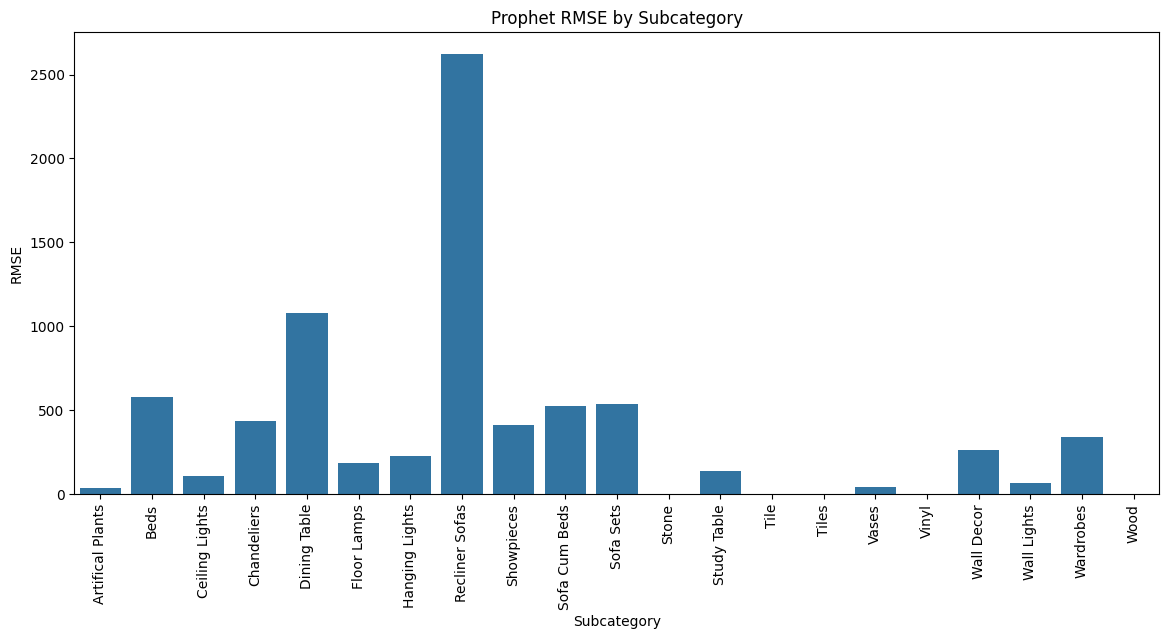

In [15]:
#RMSE
plt.figure(figsize=(14,6))

sns.barplot(
    data=prophet_eval_df,
    x="Sub_Category",
    y="RMSE"
)

plt.xticks(rotation=90)

plt.title("Prophet RMSE by Subcategory")
plt.xlabel("Subcategory")
plt.ylabel("RMSE")

plt.show()

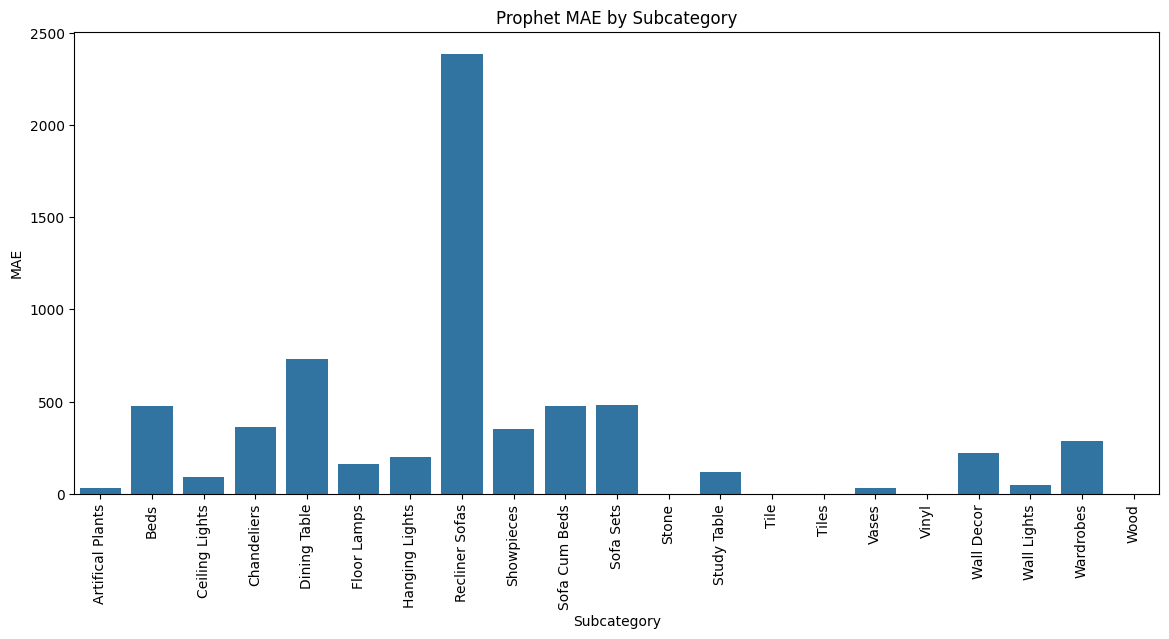

In [16]:
#MAE
plt.figure(figsize=(14,6))

sns.barplot(
    data=prophet_eval_df,
    x="Sub_Category",
    y="MAE"
)

plt.xticks(rotation=90)

plt.title("Prophet MAE by Subcategory")
plt.xlabel("Subcategory")
plt.ylabel("MAE")

plt.show()

ARIMA forecasting

In [17]:
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error
)
import numpy as np

Train ARIMA

In [18]:
arima_results = []

for subcat in subcat_df["Sub_Category"].unique():

    print(f"\n==== {subcat} ====")

    data = (
        subcat_df[
            subcat_df["Sub_Category"] == subcat
        ]
        .sort_values("Date")
    )

    ts = (
        data
        .set_index("Date")["Price"]
    )

    # Train-test split
    train = ts[:'2025-06-01']
    test = ts['2025-07-01':]

    # Skip if insufficient data
    if len(train) < 12 or len(test) == 0:
        print("Not enough observations.")
        continue

    # Build model
    model = ARIMA(
        train,
        order=(1,1,1)
    )

    model_fit = model.fit()

    # Forecast
    forecast = model_fit.forecast(
        steps=len(test)
    )

    # Evaluation
    mae = mean_absolute_error(
        test,
        forecast
    )

    rmse = np.sqrt(
        mean_squared_error(
            test,
            forecast
        )
    )

    print(
        f"MAE={mae:.2f}, "
        f"RMSE={rmse:.2f}"
    )

    arima_results.append(
        {
            "Sub_Category": subcat,
            "MAE": mae,
            "RMSE": rmse
        }
    )


==== Artifical Plants ====
MAE=44.75, RMSE=55.25

==== Beds ====
MAE=1589.58, RMSE=2179.11

==== Ceiling Lights ====
MAE=443.76, RMSE=603.25

==== Chandeliers ====
MAE=881.48, RMSE=1137.44

==== Dining Table ====


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_date

MAE=3464.89, RMSE=4165.54

==== Floor Lamps ====
MAE=385.65, RMSE=443.78

==== Hanging Lights ====
MAE=319.26, RMSE=351.90

==== Recliner Sofas ====
MAE=4945.67, RMSE=5881.36

==== Showpieces ====


/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used

MAE=848.40, RMSE=1045.60

==== Sofa Cum Beds ====
MAE=985.14, RMSE=1161.70

==== Sofa Sets ====
MAE=999.13, RMSE=1180.17

==== Stone ====
MAE=7.44, RMSE=9.11

==== Study Table ====


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_date

MAE=420.45, RMSE=500.63

==== Tile ====
MAE=1.61, RMSE=2.00

==== Tiles ====
MAE=1.83, RMSE=2.33

==== Vases ====
MAE=148.78, RMSE=188.11

==== Vinyl ====
MAE=2.41, RMSE=2.67

==== Wall Decor ====


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_date

MAE=540.42, RMSE=617.02

==== Wall Lights ====
MAE=136.65, RMSE=152.20

==== Wardrobes ====
MAE=1294.97, RMSE=1504.45

==== Wood ====
MAE=1.35, RMSE=1.60


/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


Evaluation metrics - ARIMS

In [19]:
arima_eval_df = pd.DataFrame(
    arima_results
)

display(
    arima_eval_df
)

arima_eval_df.to_csv(
    "arima_evaluation.csv",
    index=False
)

print(
    "Saved: arima_evaluation.csv"
)

,Sub_Category,MAE,RMSE
0,Artifical Plants,44.750169,55.253979
1,Beds,1589.576572,2179.108000
2,Ceiling Lights,443.763993,603.251245
3,Chandeliers,881.475415,1137.436228
4,Dining Table,3464.885567,4165.544674
5,Floor Lamps,385.651031,443.780918
6,Hanging Lights,319.255119,351.896797
7,Recliner Sofas,4945.666859,5881.357776
8,Showpieces,848.396601,1045.603857
9,Sofa Cum Beds,985.144364,1161.703919


Saved: arima_evaluation.csv


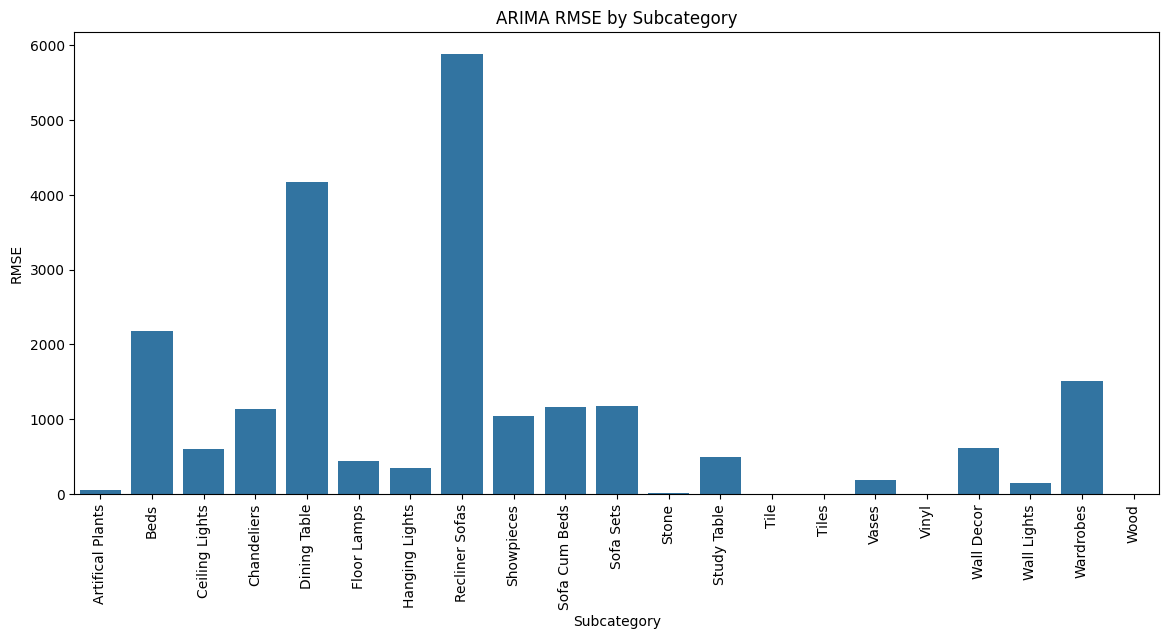

In [20]:
#RMSE
plt.figure(figsize=(14,6))

sns.barplot(
    data=arima_eval_df,
    x="Sub_Category",
    y="RMSE"
)

plt.xticks(rotation=90)
plt.title("ARIMA RMSE by Subcategory")
plt.xlabel("Subcategory")
plt.ylabel("RMSE")

plt.show()

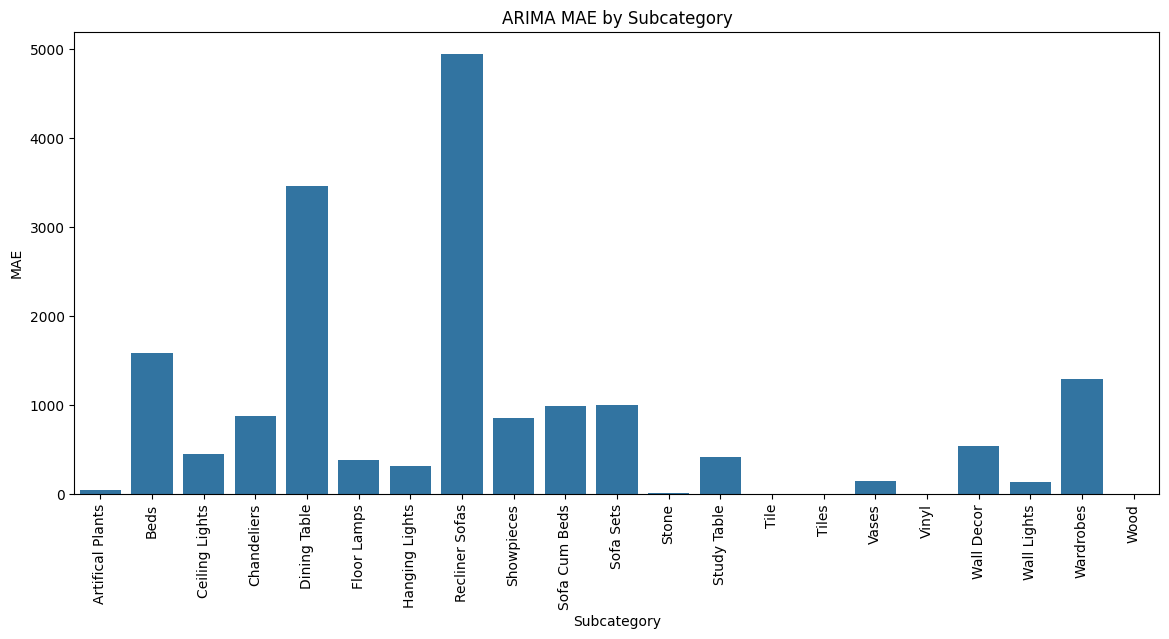

In [21]:
#MAE
plt.figure(figsize=(14,6))

sns.barplot(
    data=arima_eval_df,
    x="Sub_Category",
    y="MAE"
)

plt.xticks(rotation=90)

plt.title("ARIMA MAE by Subcategory")
plt.xlabel("Subcategory")
plt.ylabel("MAE")

plt.show()

Comparison between Prophet and ARIMA evaluation metrics:

In [22]:
comparison = pd.DataFrame({
    "Model": [
        "Prophet",
        "ARIMA"
    ],
    "MAE": [
        prophet_eval_df["MAE"].mean(),
        arima_eval_df["MAE"].mean()
    ],
    "RMSE": [
        prophet_eval_df["RMSE"].mean(),
        arima_eval_df["RMSE"].mean()
    ]
})

display(comparison)

,Model,MAE,RMSE
0,Prophet,307.793179,361.221434
1,ARIMA,831.600650,1008.819931


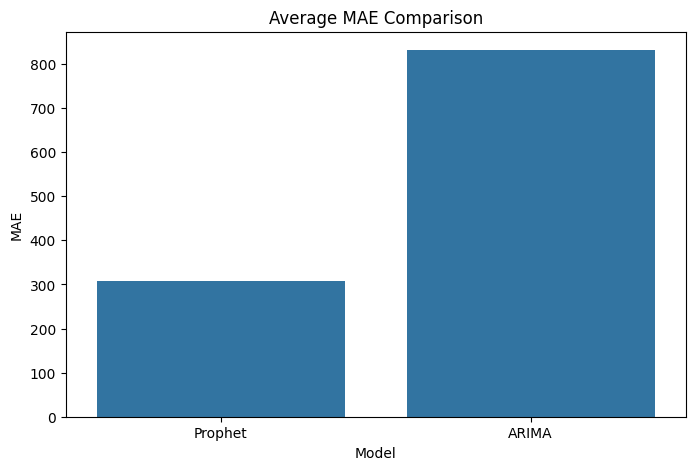

In [23]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=comparison,
    x="Model",
    y="MAE"
)

plt.title("Average MAE Comparison")
plt.ylabel("MAE")

plt.show()

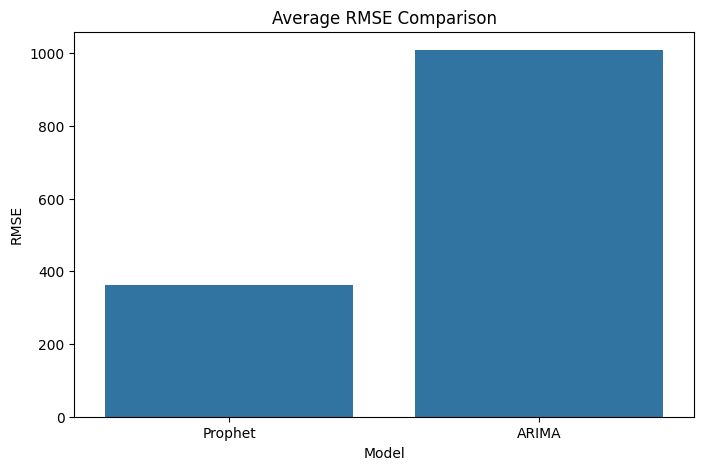

In [24]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=comparison,
    x="Model",
    y="RMSE"
)

plt.title("Average RMSE Comparison")
plt.ylabel("RMSE")

plt.show()

GRU forecasting

(80145, 13)


,Date,Category,Sub_Category,Product_Name,Price,Source,Year,Month,Quarter,Lag_1,Lag_2,Lag_3,Rolling_Mean_3
18522,2022-01-01,Furniture,Wardrobes,2 Door,13572.18,Urbanladder.com,2022,1,1,21430.17,8571.64,28573.80,14524.663333
18576,2022-01-01,Furniture,Wardrobes,2 Door,14286.54,Urbanladder.com,2022,1,1,13572.18,21430.17,8571.64,16429.630000
18630,2022-01-01,Furniture,Wardrobes,2 Door,27859.43,Urbanladder.com,2022,1,1,14286.54,13572.18,21430.17,18572.716667
18684,2022-01-01,Furniture,Wardrobes,2 Door,39289.24,Urbanladder.com,2022,1,1,27859.43,14286.54,13572.18,27145.070000
18738,2022-01-01,Furniture,Wardrobes,2 Door,9286.00,Urbanladder.com,2022,1,1,39289.24,27859.43,14286.54,25478.223333


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ gru (GRU)                       │ (None, 64)             │        14,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 16,513 (64.50 KB)

 Trainable params: 16,513 (64.50 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
802/802 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 0.0019 - val_loss: 5.4314e-06
Epoch 2/50
802/802 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 3.2052e-06 - val_loss: 4.4549e-06
Epoch 3/50
802/802 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 2.0964e-06 - val_loss: 2.8622e-06
Epoch 4/50
802/802 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 2.2434e-06 - val_loss: 2.6028e-06
Epoch 5/50
802/802 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 2.6950e-06 - val_loss: 3.0488e-06
Epoch 6/50
802/802 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 4.6187e-06 - val_loss: 6.4768e-07
Epoch 7/50
802/802 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 4.4251e-06 - val_loss: 5.8838e-07
Epoch 8/50
802/802 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 4.4923e-06 - val_loss: 9.6180e-06
Epoch 9/50
802/802 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 3.5111e-06 - val_loss: 2.0573e-06
Epoch 10/50
802/802 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 4.6993e-06 - val_loss: 8.8352e-07
Epoch 11/50
802/802 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 3.

,Model,MAE,RMSE
0,GRU,315.218305,413.249938


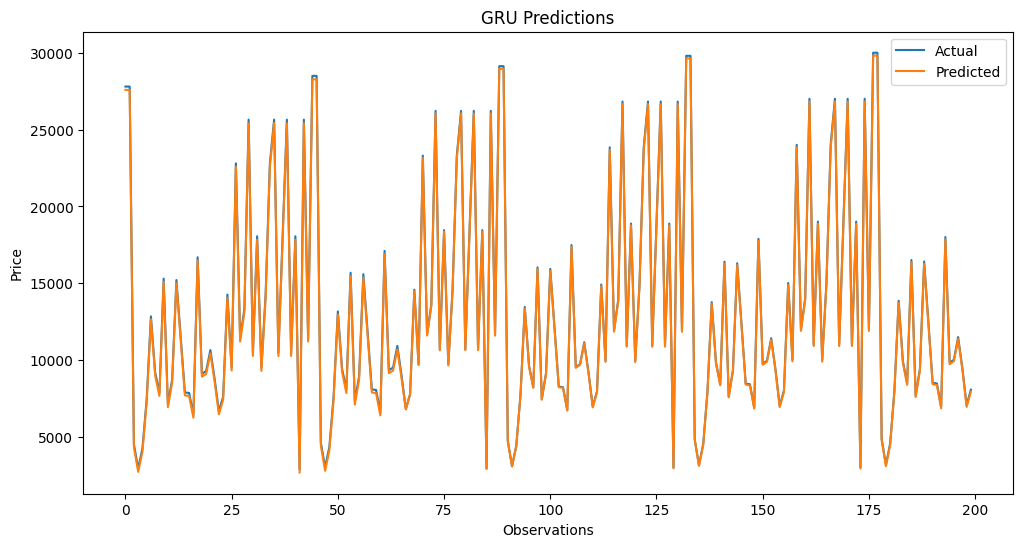

In [25]:
#Preparing dataset
gru_df = df.copy()

gru_df = gru_df.dropna()

print(gru_df.shape)
display(gru_df.head())

#Categories
from sklearn.preprocessing import LabelEncoder

le_cat = LabelEncoder()
le_sub = LabelEncoder()

gru_df["Category_Encoded"] = (
    le_cat.fit_transform(
        gru_df["Category"]
    )
)

gru_df["SubCategory_Encoded"] = (
    le_sub.fit_transform(
        gru_df["Sub_Category"]
    )
)

#Define features
features = [
    "Year",
    "Month",
    "Quarter",
    "Category_Encoded",
    "SubCategory_Encoded",
    "Lag_1",
    "Lag_2",
    "Lag_3",
    "Rolling_Mean_3"
]

target = "Price"

#Scale data
from sklearn.preprocessing import MinMaxScaler

scaler_x = MinMaxScaler()
scaler_y = MinMaxScaler()

X = scaler_x.fit_transform(
    gru_df[features]
)

y = scaler_y.fit_transform(
    gru_df[[target]]
)

#train-test split
split = int(
    0.8 * len(X)
)

X_train = X[:split]
X_test = X[split:]

y_train = y[:split]
y_test = y[split:]

X_train = X_train.reshape(
    (
        X_train.shape[0],
        1,
        X_train.shape[1]
    )
)

X_test = X_test.reshape(
    (
        X_test.shape[0],
        1,
        X_test.shape[1]
    )
)

#Build GRU
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    GRU,
    Dense
)

model = Sequential()

model.add(
    GRU(
        64,
        activation="tanh",
        input_shape=(
            X_train.shape[1],
            X_train.shape[2]
        )
    )
)

model.add(Dense(32))

model.add(Dense(1))

model.compile(
    optimizer="adam",
    loss="mse"
)

model.summary()

#Train
history = model.fit(
    X_train,
    y_train,
    epochs=50,
    batch_size=64,
    validation_split=0.2,
    verbose=1
)

#Prediction
predictions = model.predict(
    X_test
)

predictions = (
    scaler_y
    .inverse_transform(
        predictions
    )
)

y_actual = (
    scaler_y
    .inverse_transform(
        y_test
    )
)

#Evaluation
gru_mae = mean_absolute_error(
    y_actual,
    predictions
)

gru_rmse = np.sqrt(
    mean_squared_error(
        y_actual,
        predictions
    )
)

print(
    "GRU MAE:",
    gru_mae
)

print(
    "GRU RMSE:",
    gru_rmse
)

import pandas as pd

gru_results = pd.DataFrame({
    "Model": ["GRU"],
    "MAE": [gru_mae],
    "RMSE": [gru_rmse]
})

gru_results.to_csv(
    "gru_evaluation.csv",
    index=False
)

print("Saved: gru_evaluation.csv")

display(gru_results)

#Plot
plt.figure(figsize=(12,6))

plt.plot(
    y_actual[:200],
    label="Actual"
)

plt.plot(
    predictions[:200],
    label="Predicted"
)

plt.title(
    "GRU Predictions"
)

plt.xlabel(
    "Observations"
)

plt.ylabel(
    "Price"
)

plt.legend()

plt.show()

Final Comparision between all three models

In [26]:
comparison = pd.DataFrame({
    "Model": [
        "Prophet",
        "ARIMA",
        "GRU"
    ],
    "MAE": [
        prophet_eval_df["MAE"].mean(),
        arima_eval_df["MAE"].mean(),
        gru_mae
    ],
    "RMSE": [
        prophet_eval_df["RMSE"].mean(),
        arima_eval_df["RMSE"].mean(),
        gru_rmse
    ]
})

display(comparison)

,Model,MAE,RMSE
0,Prophet,307.793179,361.221434
1,ARIMA,831.600650,1008.819931
2,GRU,315.218305,413.249938


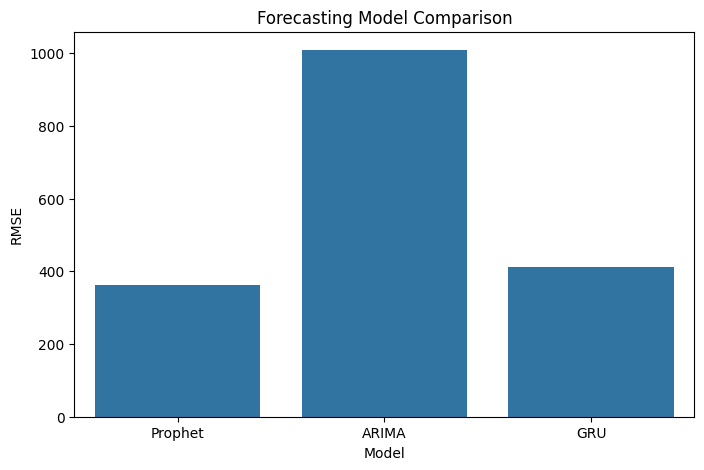

In [27]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=comparison,
    x="Model",
    y="RMSE"
)

plt.title(
    "Forecasting Model Comparison"
)

plt.ylabel(
    "RMSE"
)

plt.show()

In [28]:
best_model = comparison.loc[
    comparison["RMSE"].idxmin()
]

print(
    f"The best performing model is "
    f"{best_model['Model']} "
    f"with RMSE "
    f"{best_model['RMSE']:.2f}."
)

The best performing model is Prophet with RMSE 361.22.


Conclusion

In [29]:
best_model = comparison.loc[
    comparison["RMSE"].idxmin()
]

print(
    f"The best performing model is "
    f"{best_model['Model']} "
    f"with RMSE of "
    f"{best_model['RMSE']:.2f}."
)

The best performing model is Prophet with RMSE of 361.22.


Automated insights

In [30]:
#Automated insights
best_model = comparison.loc[
    comparison["RMSE"].idxmin()
]

worst_model = comparison.loc[
    comparison["RMSE"].idxmax()
]

print(
    f"Best Model: {best_model['Model']}"
)
print(
    f"RMSE: {best_model['RMSE']:.2f}"
)

print(
    f"Worst Model: {worst_model['Model']}"
)
print(
    f"RMSE: {worst_model['RMSE']:.2f}"
)

#Automated conclusion
if best_model["Model"] == "GRU":
    print(
        "GRU achieved the highest forecasting accuracy. "
        "Deep learning was more effective in learning "
        "complex price patterns."
    )
elif best_model["Model"] == "Prophet":
    print(
        "Prophet achieved the highest forecasting accuracy."
    )
else:
    print(
        "ARIMA achieved the highest forecasting accuracy."
    )

#Save all outputs
comparison.to_csv(
    "model_comparison.csv",
    index=False
)

summary.to_csv(
    "growth_summary.csv",
    index=False
)

future_summary_df.to_csv(
    "future_summary.csv",
    index=False
)

#Create Dashboard dataset
dashboard_data = {
    "Total Products":
        df["Product_Name"].nunique(),

    "Historical Records":
        len(df),

    "Subcategories":
        df["Sub_Category"].nunique(),

    "Best Model":
        best_model["Model"],

    "Best RMSE":
        best_model["RMSE"]
}

dashboard_df = pd.DataFrame(
    [dashboard_data]
)

display(dashboard_df)



Best Model: Prophet
RMSE: 361.22
Worst Model: ARIMA
RMSE: 1008.82
Prophet achieved the highest forecasting accuracy.


,Total Products,Historical Records,Subcategories,Best Model,Best RMSE
0,33,80946,21,Prophet,361.221434
